# Morphological Modelling for Strategic Intelligence
**Master Thesis — ESCP Business School, 2026**  
**Author:** Luca Osculati

---

This notebook provides a visual overview of the empirical results from the thesis.  
The pipeline applies Principal Component Analysis (PCA) to per-move positional features extracted from 9,999 Stockfish self-play chess games, testing three progressively stronger hypotheses about the existence of a stable, low-dimensional morphological structure in strategic dynamics.

| Hypothesis | Claim |
|-----------|-------|
| **H1** | Variance in game states concentrates in a small number of latent directions |
| **H2** | The dominant latent directions are stable under bootstrap resampling |
| **H3** | Projected trajectories exhibit systematic regional organization by outcome |

In [1]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

BASE = 'data/outputs'

---
## H1 — Structured Dimensional Reduction

The first hypothesis requires that variance in game states is not uniformly dispersed across all 18 features, but concentrates in a small number of latent directions.  
Under purely unstructured variability, each component would explain roughly 1/18 ≈ 5.6% of total variance.

**Result:** the first two principal components explain ~26% of total variance for both White and Black — more than double the unstructured baseline.

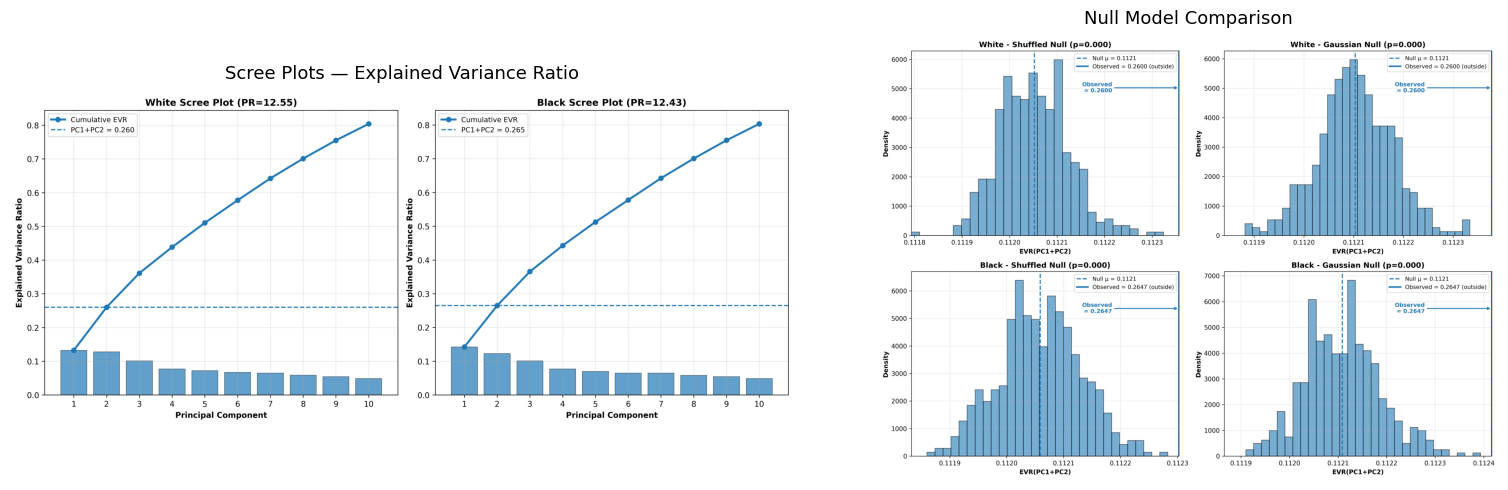

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, fname, title in zip(axes,
    [f'{BASE}/h1_scree_plots.png', f'{BASE}/h1_null_comparisons.png'],
    ['Scree Plots — Explained Variance Ratio', 'Null Model Comparison']):
    img = mpimg.imread(fname)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=13, pad=10)

plt.tight_layout()
plt.show()

---
## H2 — Stability of Latent Directions

H2 tests whether the extracted principal axes are intrinsic geometric features of the system, or merely sampling artifacts.  
Stability is assessed via stratified bootstrap resampling (80 iterations, 80% of games each): the leading eigenvectors are re-estimated on each subsample and their alignment with the full-sample solution is measured via cosine similarity.

**Result:** cosine similarities are consistently above 0.99 for White and above 0.98 for Black, confirming structural robustness.

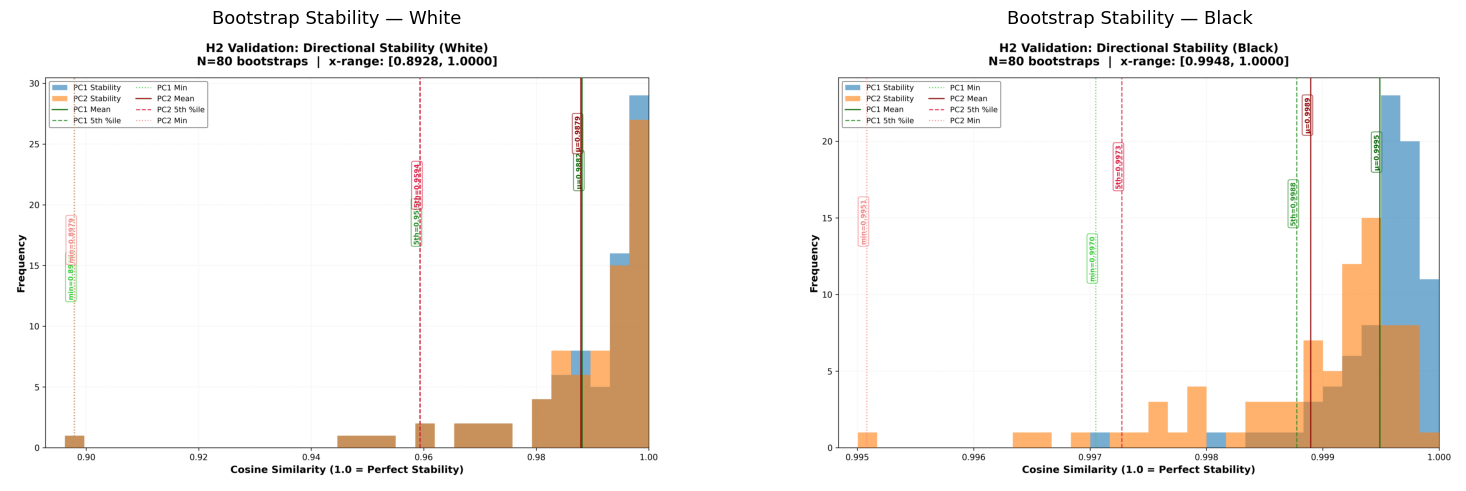

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, fname, title in zip(axes,
    [f'{BASE}/h2_white_zoom.png', f'{BASE}/h2_black_fullrange.png'],
    ['Bootstrap Stability — White', 'Bootstrap Stability — Black']):
    img = mpimg.imread(fname)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=13, pad=10)

plt.tight_layout()
plt.show()

---
## H3 — Behavioral Relevance of Latent Trajectories

H3 requires that the latent geometry be behaviorally informative with respect to game outcomes (Win/Draw/Loss), even though PCA was estimated without using outcome information.

For each trajectory, geometric drift is computed as:

$$\Delta z_1 = z_1(T_{\text{final}}) - z_1(t_0)$$

**Result:** wins drift systematically toward negative PC1, losses toward positive PC1, and draws remain near zero. The Mann-Whitney test yields p < 10⁻³⁰⁰ with rank-biserial r ≈ 0.60.

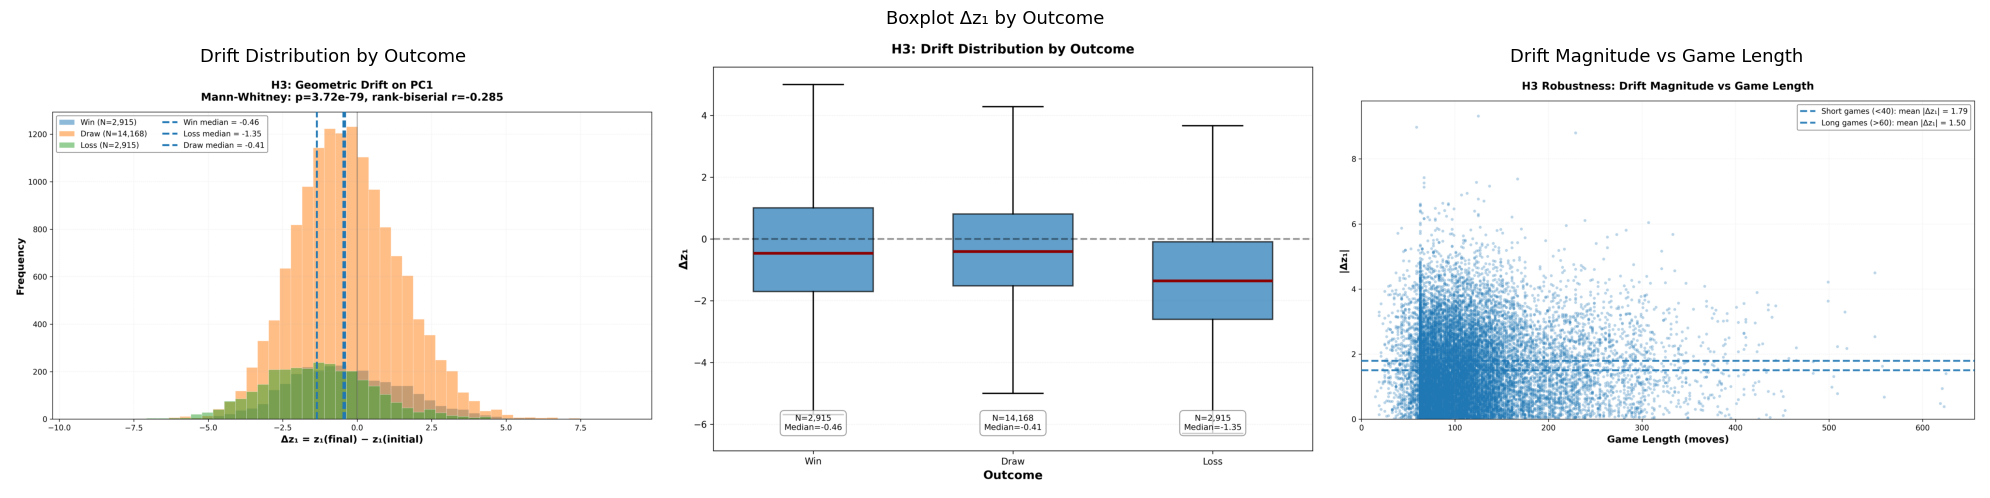

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, fname, title in zip(axes,
    [f'{BASE}/h3_drift_hist.png', f'{BASE}/h3_drift_boxplot.png', f'{BASE}/h3_len_scatter.png'],
    ['Drift Distribution by Outcome', 'Boxplot Δz₁ by Outcome', 'Drift Magnitude vs Game Length']):
    img = mpimg.imread(fname)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=13, pad=10)

plt.tight_layout()
plt.show()

---
## Unified PCA Trajectories

Mean PCA coordinates at each move for Win/Draw/Loss games, with standard error bands.  
The trajectories are estimated in a **unified** PCA space (White and Black projected together), so regime separation is not mechanically induced by the projection.

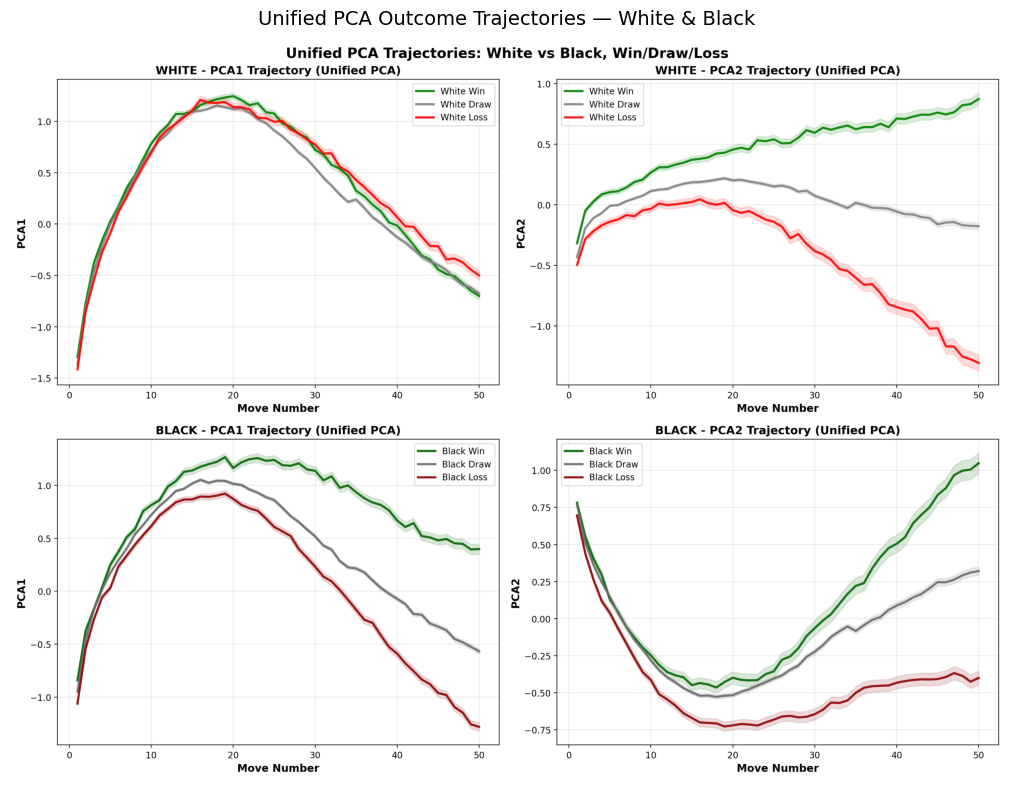

In [5]:
img = mpimg.imread(f'{BASE}/chess_unified_pca.png')
fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(img)
ax.axis('off')
ax.set_title('Unified PCA Outcome Trajectories — White & Black', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

---
## Loading Profiles — PC1 and PC2

The loading profiles show which features drive each principal component.

- **PC1** is dominated by tactical tension features: `mobility`, `captures_avail`, `attack_overlap`
- **PC2** captures structural capital: `cnt_pawn`, `pawns_passed_diff`, `material`

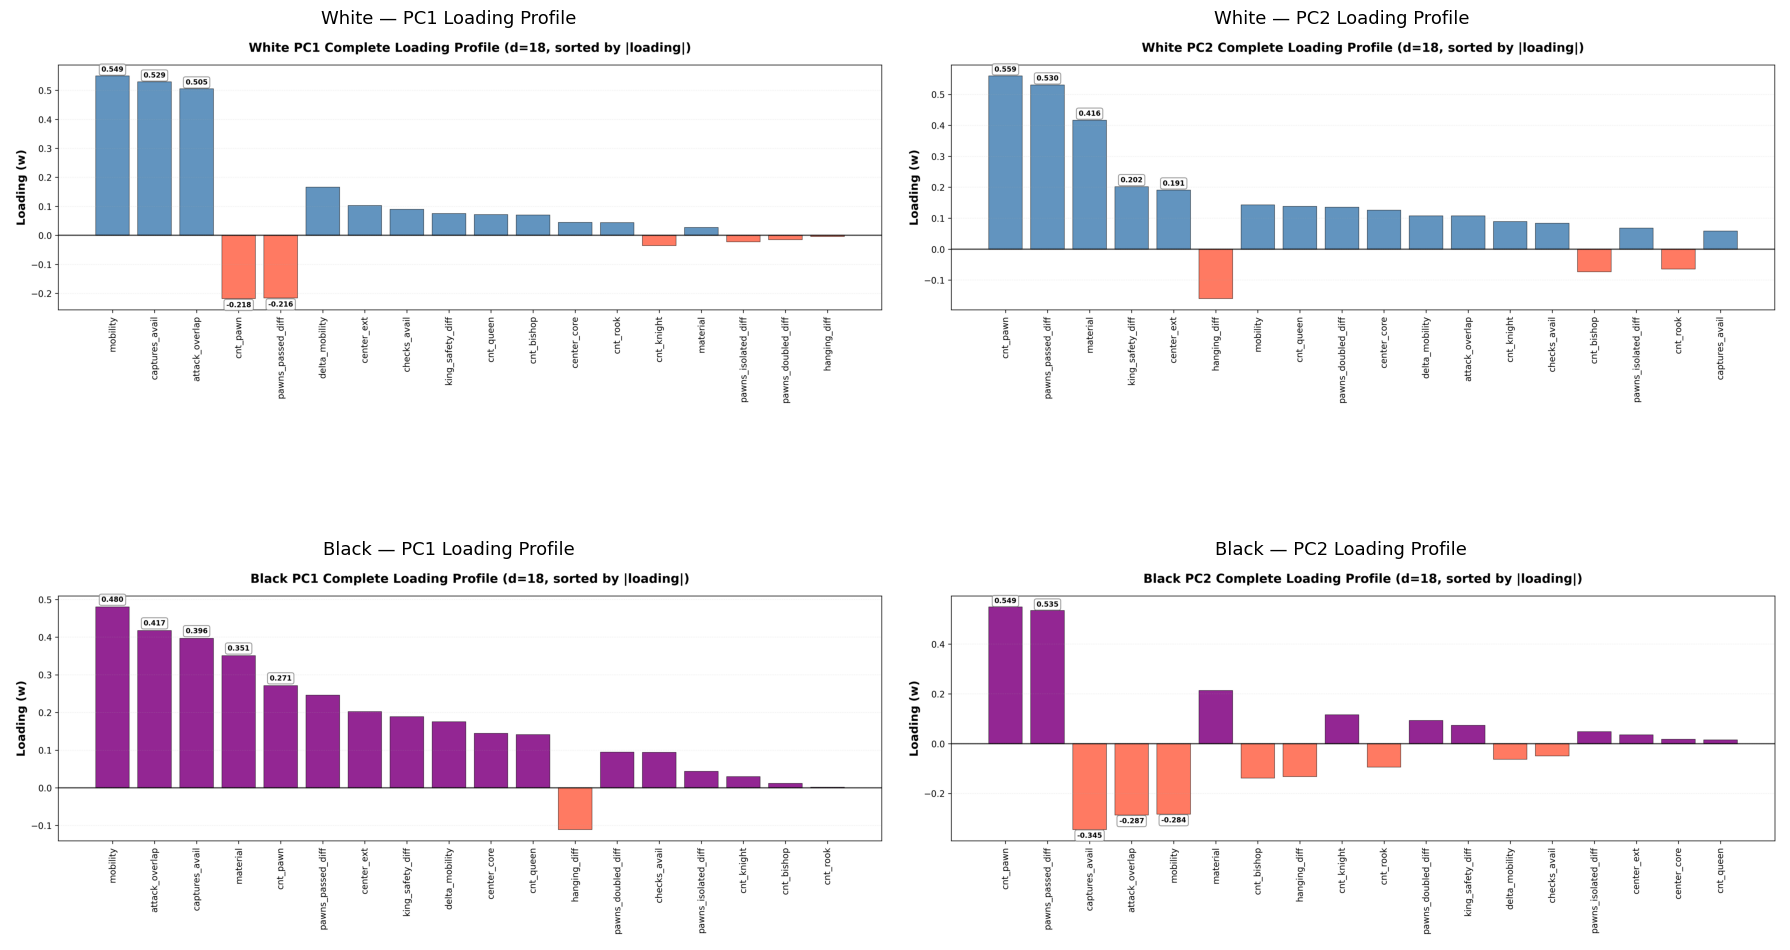

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

files = [
    (f'{BASE}/loading_profiles/white_pc1_loading_profile.png', 'White — PC1 Loading Profile'),
    (f'{BASE}/loading_profiles/white_pc2_loading_profile.png', 'White — PC2 Loading Profile'),
    (f'{BASE}/loading_profiles/black_pc1_loading_profile.png', 'Black — PC1 Loading Profile'),
    (f'{BASE}/loading_profiles/black_pc2_loading_profile.png', 'Black — PC2 Loading Profile'),
]

for ax, (fname, title) in zip(axes.flatten(), files):
    img = mpimg.imread(fname)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=13, pad=10)

plt.tight_layout()
plt.show()

### Top Loadings Table

In [7]:
df = pd.read_csv(f'{BASE}/loading_profiles/loadings_comparison.csv')
df

,Unnamed: 0,White_PC1,Black_PC1,White_PC2,Black_PC2
0,mobility,0.549467,0.479996,0.143313,-0.283898
1,captures_avail,0.529158,0.396497,0.058351,-0.345420
2,attack_overlap,0.505138,0.417237,0.107403,-0.287284
3,cnt_pawn,-0.218160,0.271286,0.559490,0.549204
4,pawns_passed_diff,-0.216274,0.246244,0.530344,0.535226
5,material,0.026901,0.350501,0.416499,0.213309
6,delta_mobility,0.165827,0.175551,0.107847,-0.062564
7,center_ext,0.103025,0.202109,0.191065,0.035365
8,king_safety_diff,0.075188,0.188677,0.201812,0.073971
9,cnt_queen,0.071574,0.141187,0.138273,0.015387


---
## Empirical Attractor Basins

Beyond directional drift, this section tests whether trajectories **persist** within bounded regions of latent space — the defining property of attractor basins.

For each trajectory, the residence share R(Ω) is computed as the fraction of moves spent inside a predefined region Ω:

$$R_i(\Omega) = \frac{1}{T_i} \sum_{t=1}^{T_i} \mathbf{1}\{z_{i,t} \in \Omega\}$$

**Key results:**

| Perspective | Axis | Region | Win median | Loss median | Separation |
|------------|------|--------|-----------|------------|------------|
| Black | PC1 | Ω_win (PC1 < −1.0) | 31% | 5% | 26 pts |
| Black | PC1 | Ω_loss (PC1 > 0.75) | 24% | 46% | 22 pts |
| White | PC2 | Ω_win (PC2 > +0.75) | 40% | 9% | 31 pts |
| White | PC2 | Ω_loss (PC2 < −0.75) | 6% | 40% | 34 pts |

The axis hosting outcome separation differs by perspective — but the mechanism is invariant: strategic performance is governed by **where trajectories reside**, not by convergence to a point.

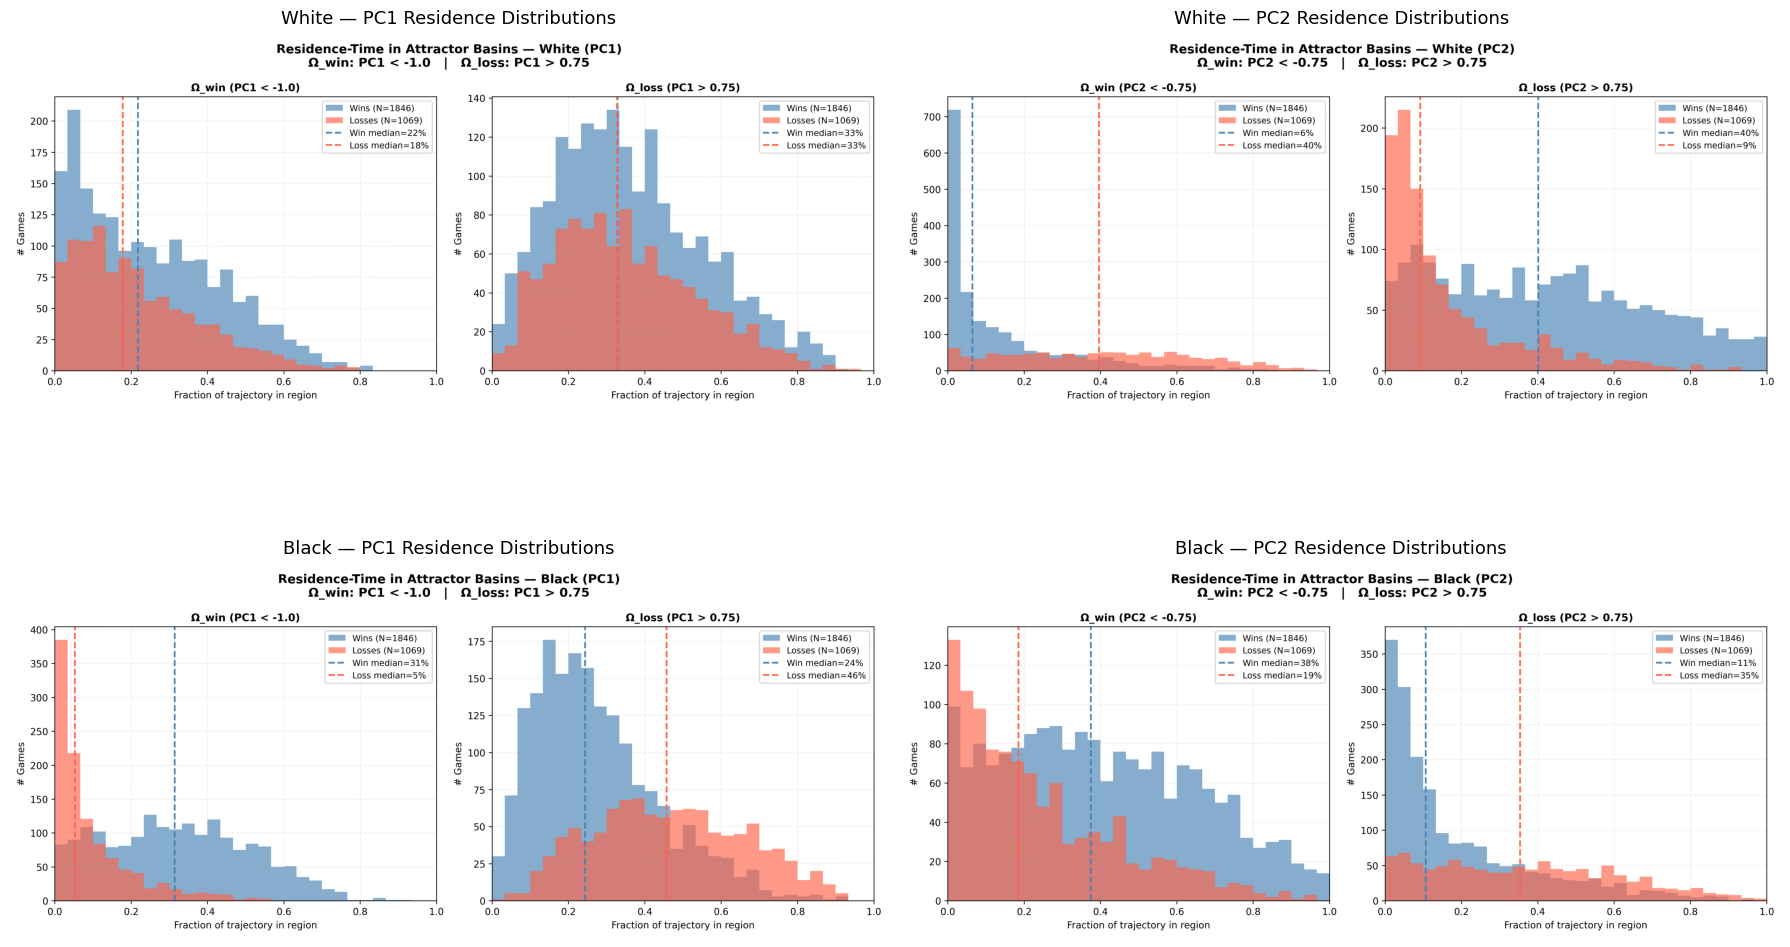

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

files = [
    (f'{BASE}/h4_residence/figures/residence_white_pc1.png', 'White — PC1 Residence Distributions'),
    (f'{BASE}/h4_residence/figures/residence_white_pc2.png', 'White — PC2 Residence Distributions'),
    (f'{BASE}/h4_residence/figures/residence_black_pc1.png', 'Black — PC1 Residence Distributions'),
    (f'{BASE}/h4_residence/figures/residence_black_pc2.png', 'Black — PC2 Residence Distributions'),
]

for ax, (fname, title) in zip(axes.flatten(), files):
    img = mpimg.imread(fname)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=13, pad=10)

plt.tight_layout()
plt.show()

---
## Conclusion

The three hypotheses are jointly supported:

- **H1** establishes non-trivial low-dimensional structure (EVR ~26%, far exceeding null baselines)
- **H2** confirms the latent axes are intrinsic and not sampling artifacts (cosine similarity > 0.99)
- **H3** demonstrates behavioral relevance without supervision (p < 10⁻³⁰⁰, r ≈ 0.60), including persistent attractor basins with large residence asymmetries by outcome

Together, these results constitute a **proof of existence** for the Morphological Framework: strategic dynamics in chess admit a latent geometric representation recoverable from unsupervised analysis of state trajectories alone.

> *"In high-dimensional environments, equilibrium may fail to appear as a point to be computed; it can instead emerge as a geometry to be measured."*  
> — Osculati (2026)